# Heart disease Prediction

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [31]:
from PIL import Image
import streamlit as st

In [32]:
df= pd.read_csv('C:/Users/ADMIN/Desktop/Hear disease/heart_disease_data.csv')
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [33]:
df.shape

(303, 14)

In [34]:
df.isnull().sum().sum()

np.int64(0)

In [38]:
df.duplicated().sum()

np.int64(1)

In [40]:
# Display duplicated row

duplicated_row = df[df.duplicated()]
duplicated_row

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [42]:
# Show all  duplicated row

duplicated_all = df[df.duplicated(keep= False)]
duplicated_all

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [43]:
df= df.drop_duplicates()
print("shape after duplicate removal:",df.shape)

shape after duplicate removal: (302, 14)


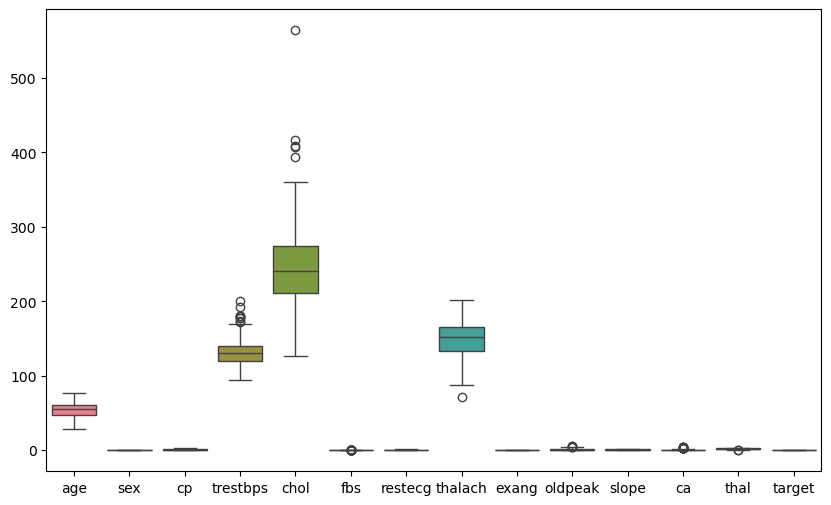

In [46]:
plt.figure(figsize=(10,6))
sns.boxplot(data =df)
plt.show()

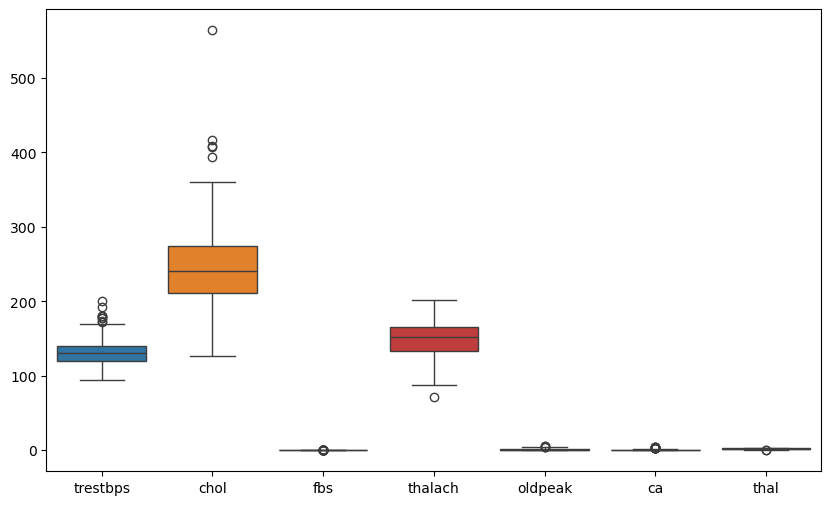

In [48]:
plt.figure(figsize=(10,6))
sns.boxplot(data =df[['trestbps','chol','fbs','thalach','oldpeak','ca','thal']])
plt.show()

In [53]:
for i in df.columns:
    Q1= df[i].quantile(0.25)
    Q3= df[i].quantile(0.75)
    IQR = Q3 -Q1
    LF = Q1 - 1.5 * IQR
    UF = Q3 + 1.5 * IQR

    df = df [ (df[i]>=LF) & (df[i]<=UF)]

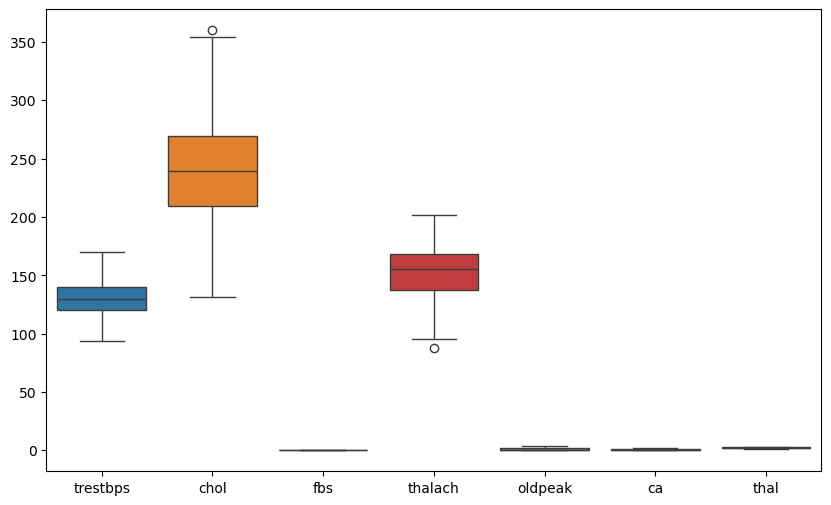

In [54]:
plt.figure(figsize=(10,6))
sns.boxplot(data =df[['trestbps','chol','fbs','thalach','oldpeak','ca','thal']])
plt.show()

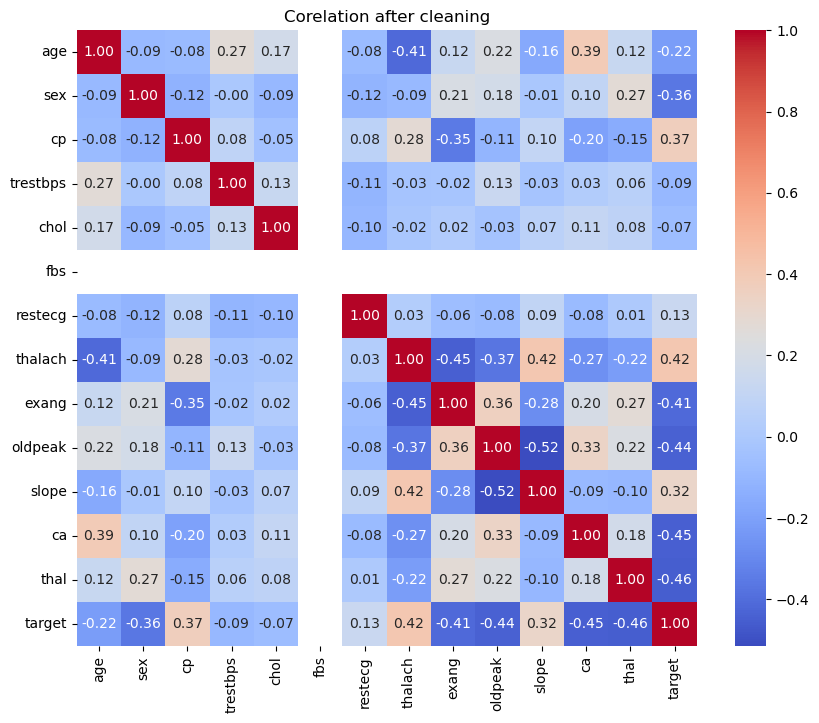

In [61]:
# correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot = True,cmap ="coolwarm",fmt ='.2f')
plt.title("Corelation after cleaning")
plt.show()

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 228 entries, 1 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       228 non-null    int64  
 1   sex       228 non-null    int64  
 2   cp        228 non-null    int64  
 3   trestbps  228 non-null    int64  
 4   chol      228 non-null    int64  
 5   fbs       228 non-null    int64  
 6   restecg   228 non-null    int64  
 7   thalach   228 non-null    int64  
 8   exang     228 non-null    int64  
 9   oldpeak   228 non-null    float64
 10  slope     228 non-null    int64  
 11  ca        228 non-null    int64  
 12  thal      228 non-null    int64  
 13  target    228 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 26.7 KB


In [63]:
# statistical measure about the data
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,228.000000,228.000000,228.000000,228.000000,228.000000,228.0,228.000000,228.000000,228.000000,228.000000,228.000000,228.00000,228.000000,228.000000
mean,53.333333,0.675439,0.942982,128.671053,242.372807,0.0,0.548246,151.070175,0.315789,0.946053,1.451754,0.47807,2.315789,0.578947
std,9.229016,0.469241,1.020190,15.349142,44.329827,0.0,0.516125,22.492963,0.465852,1.035422,0.587945,0.69893,0.560299,0.494814
min,29.000000,0.000000,0.000000,94.000000,131.000000,0.0,0.000000,88.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
25%,45.000000,0.000000,0.000000,120.000000,209.750000,0.0,0.000000,137.500000,0.000000,0.000000,1.000000,0.00000,2.000000,0.000000
50%,54.000000,1.000000,1.000000,130.000000,239.000000,0.0,1.000000,155.000000,0.000000,0.600000,1.500000,0.00000,2.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,269.250000,0.0,1.000000,168.250000,1.000000,1.600000,2.000000,1.00000,3.000000,1.000000
max,76.000000,1.000000,3.000000,170.000000,360.000000,0.0,2.000000,202.000000,1.000000,4.000000,2.000000,2.00000,3.000000,1.000000


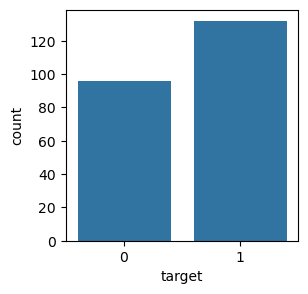

In [64]:
plt.figure(figsize =(3,3))
sns.countplot(x='target', data=df)
plt.show()

In [65]:
# checking the distribution of Target Variable
df['target'].value_counts()

target
1    132
0     96
Name: count, dtype: int64

## 1 ---> Defective Heart
## 0 ---> Healthy Heart

In [66]:
X= df.drop(['target'],axis=1)
y = df['target']

## spliting the data into training and testing data

In [67]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, stratify =y, random_state =42)

In [68]:
# (stratify =y)--- it will split the data similarily in a 
#so there is the possibility that all the values in x test contain 0. So, when you apply this 
# it will distributed in the even manner

In [69]:
print(f"X_train size:",X_train.shape)
print(f"X_test size:",X_test.shape)
print(f"y_train size:",y_train.shape)
print(f"y_test size:",y_test.shape)

X_train size: (182, 13)
X_test size: (46, 13)
y_train size: (182,)
y_test size: (46,)


# model training

In [70]:
model =LogisticRegression()

## Training the Logistic Regression model with training data

In [71]:
model.fit(X_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## Model evaluation

In [80]:
# Accuracy score on training data
X_train_pred = model.predict(X_train)
training_accuracy_score = accuracy_score(X_train_pred, y_train)
print(' Accuracy on training data:',training_accuracy_score)

 Accuracy on training data: 0.8736263736263736


In [81]:
# Accuracy score on testing data
y_test_pred = model.predict(X_test)
testing_accuracy_score = accuracy_score(y_test_pred, y_test)
print(' Accuracy on testing data:',testing_accuracy_score)

 Accuracy on testing data: 0.8695652173913043


In [82]:
from sklearn.metrics import confusion_matrix, classification_report
cm_lr = confusion_matrix(y_test_pred, y_test)
cm_lr

array([[15,  2],
       [ 4, 25]])

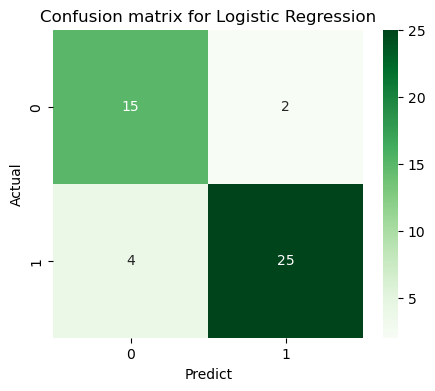

In [85]:
# correlation matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot = True,cmap ="Greens", fmt ='d')
plt.title("Confusion matrix for Logistic Regression")
plt.xlabel('Predict')
plt.ylabel('Actual')
plt.show()

# Building a predicted system (for future predication)

In [74]:
input_data = (41,0,1,130,204,0,0,172,0,1.4,2,0,2)
# current its is tuple data type so we have to convert into  numpy array 

input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped =input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]==0):
    print('The person have healthy heart')
else:
    print('The person have heart disease')

[1]
The person have heart disease


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [75]:
input_data = (62,0,0,140,268,0,0,160,0,3.6,0,2,2)
# current its is tuple data type so we have to convert into  numpy array 

input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped =input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]==0):
    print('The person have healthy heart')
else:
    print('The person have heart disease')

[0]
The person have healthy heart


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [76]:
input_data = (61,0,0,145,307,0,0,146,1,1,1,0,3)
# current its is tuple data type so we have to convert into  numpy array 

input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped =input_data_as_numpy_array.reshape(1,-1)

In [77]:
prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]==0):
    print('The person have healthy heart')
else:
    print('The person have heart disease')

[0]
The person have healthy heart


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
